In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("C:/Users/wilbe/Downloads/Dataset B/2B.tsv", sep = '\t')

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Customer ID,Gender,Birth Date,Married,Dependents,Number of Dependents,Country,City,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Internet Service,Internet Type,Avg Monthly GB Download,Premium Tech Support,Streaming Movies,Streaming Music,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Refunds,Satisfaction Score
0,8779-QRDMV,Male,1946/07/17,No,No,0,United States,Los Angeles,0,1,0.00,Yes,DSL,8,No,Yes,No,Month-to-Month,Yes,Bank Withdrawal,39.65,0.00,3
1,7495-OOKFY,Female,1950/11/12,Yes,Yes,1,United States,Los Angeles,1,8,48.85,Yes,Fiber Optic,17,No,No,No,Month-to-Month,Yes,Credit Card,80.65,0.00,3
2,1658-BYGOY,Male,1953/03/21,No,Yes,3,United States,Los Angeles,0,18,11.33,Yes,Fiber Optic,52,No,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,45.61,2
3,4598-XLKNJ,Female,1946/03/08,Yes,Yes,1,United States,Inglewood,1,25,19.76,Yes,Fiber Optic,12,No,Yes,No,Month-to-Month,Yes,Bank Withdrawal,98.50,13.43,2
4,4846-WHAFZ,Female,1944/04/02,Yes,Yes,1,United States,Whittier,1,37,6.33,Yes,Fiber Optic,14,No,No,No,Month-to-Month,Yes,Bank Withdrawal,76.50,0.00,2


In [4]:
df.shape

(7043, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Birth Date                         7043 non-null   object 
 3   Married                            7043 non-null   object 
 4   Dependents                         7043 non-null   object 
 5   Number of Dependents               7043 non-null   int64  
 6   Country                            7043 non-null   object 
 7   City                               7043 non-null   object 
 8   Number of Referrals                7043 non-null   int64  
 9   Tenure in Months                   7043 non-null   int64  
 10  Avg Monthly Long Distance Charges  7043 non-null   float64
 11  Internet Service                   7043 non-null   objec

In [6]:
df = df.drop('Customer ID', axis = 1)

In [7]:
df['Internet Service'].value_counts()

Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

In [8]:
df['Internet Type'].fillna('No Service', inplace=True)

In [9]:
df["Birth Date"] = pd.to_datetime(df["Birth Date"], format="%Y/%m/%d")

def calculate_age(birth_date):
    today = datetime.today()
    return today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))

df["Age"] = df["Birth Date"].apply(calculate_age)

In [10]:
df = df.drop('Birth Date', axis = 1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Married                            7043 non-null   object 
 2   Dependents                         7043 non-null   object 
 3   Number of Dependents               7043 non-null   int64  
 4   Country                            7043 non-null   object 
 5   City                               7043 non-null   object 
 6   Number of Referrals                7043 non-null   int64  
 7   Tenure in Months                   7043 non-null   int64  
 8   Avg Monthly Long Distance Charges  7043 non-null   float64
 9   Internet Service                   7043 non-null   object 
 10  Internet Type                      7043 non-null   object 
 11  Avg Monthly GB Download            7043 non-null   int64

In [12]:
df['Gender'].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [13]:
df['Married'].value_counts()

Married
No     3641
Yes    3402
Name: count, dtype: int64

In [14]:
df['Dependents'].value_counts()

Dependents
No     5416
Yes    1627
Name: count, dtype: int64

In [15]:
df['Country'].value_counts()

Country
United States    7043
Name: count, dtype: int64

In [16]:
df['City'].value_counts()

City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Jacumba               2
South Lake Tahoe      2
Johannesburg          2
Eldridge              2
Holtville             2
Name: count, Length: 1106, dtype: int64

In [17]:
df['Internet Service'].value_counts()

Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

In [18]:
df['Internet Type'].value_counts()

Internet Type
Fiber Optic    3035
DSL            1652
No Service     1526
Cable           830
Name: count, dtype: int64

In [19]:
df['Premium Tech Support'].value_counts()

Premium Tech Support
No     4999
Yes    2044
Name: count, dtype: int64

In [20]:
df['Streaming Movies'].value_counts()

Streaming Movies
No     4311
Yes    2732
Name: count, dtype: int64

In [21]:
df['Streaming Music'].value_counts()

Streaming Music
No     4555
Yes    2488
Name: count, dtype: int64

In [22]:
df['Contract'].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

In [23]:
df['Paperless Billing'].value_counts()

Paperless Billing
Yes    4171
No     2872
Name: count, dtype: int64

In [24]:
df['Payment Method'].value_counts()

Payment Method
Bank Withdrawal    3909
Credit Card        2749
Mailed Check        385
Name: count, dtype: int64

In [25]:
df = df.drop(['Country', 'City'], axis = 1)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Married                            7043 non-null   object 
 2   Dependents                         7043 non-null   object 
 3   Number of Dependents               7043 non-null   int64  
 4   Number of Referrals                7043 non-null   int64  
 5   Tenure in Months                   7043 non-null   int64  
 6   Avg Monthly Long Distance Charges  7043 non-null   float64
 7   Internet Service                   7043 non-null   object 
 8   Internet Type                      7043 non-null   object 
 9   Avg Monthly GB Download            7043 non-null   int64  
 10  Premium Tech Support               7043 non-null   object 
 11  Streaming Movies                   7043 non-null   objec

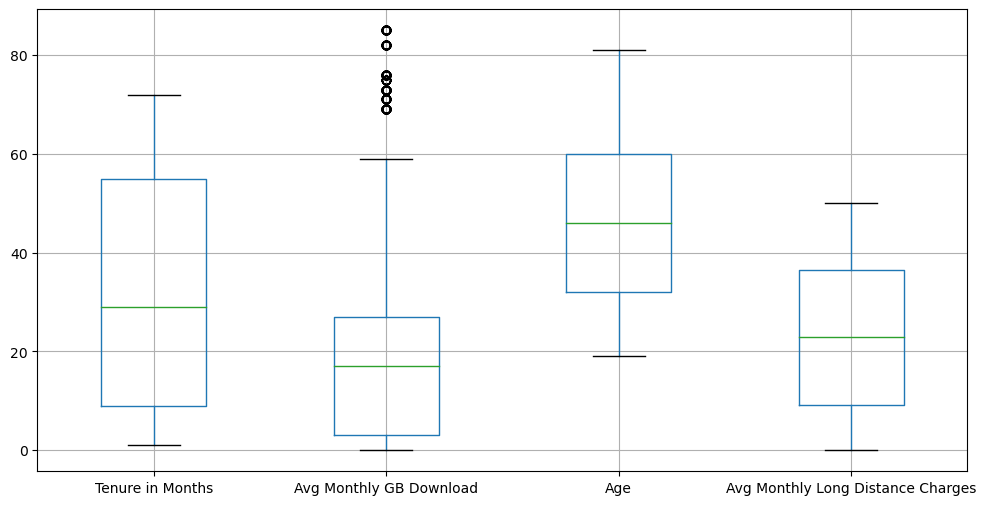

In [27]:
plt.figure(figsize=(12, 6)) 
boxplot = df.boxplot(column=['Tenure in Months','Avg Monthly GB Download','Age', 'Avg Monthly Long Distance Charges']) 
plt.show()

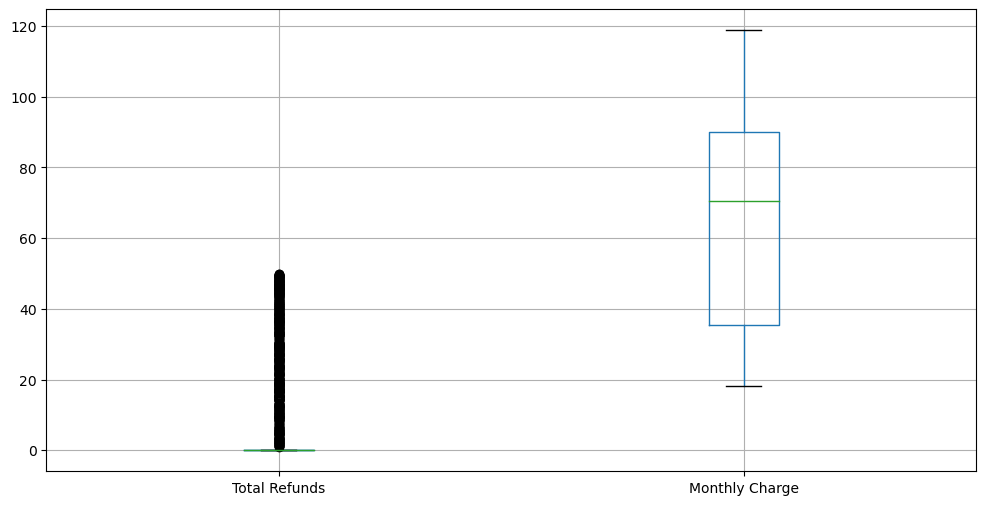

In [28]:
plt.figure(figsize=(12, 6)) 
boxplot = df.boxplot(column=['Total Refunds', 'Monthly Charge']) 
plt.show()

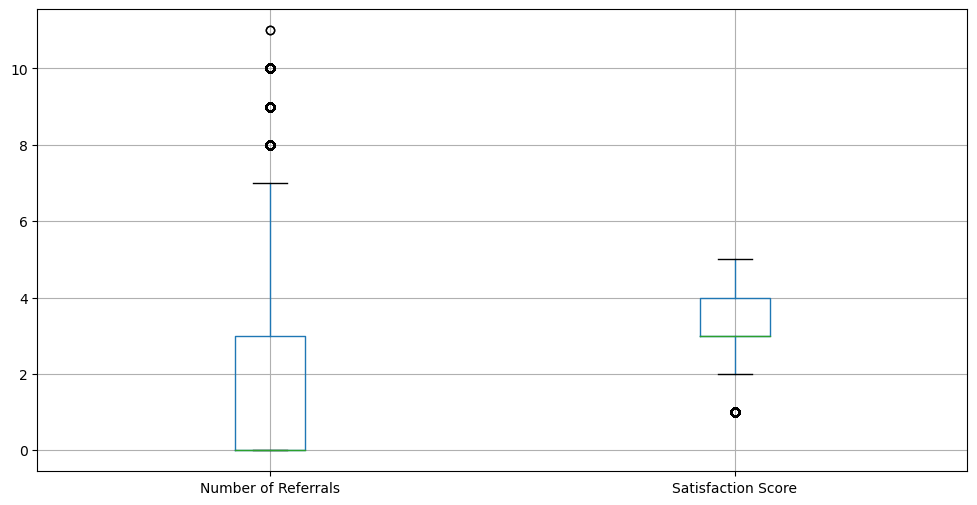

In [29]:
plt.figure(figsize=(12, 6)) 
boxplot = df.boxplot(column=['Number of Referrals','Satisfaction Score']) 
plt.show()

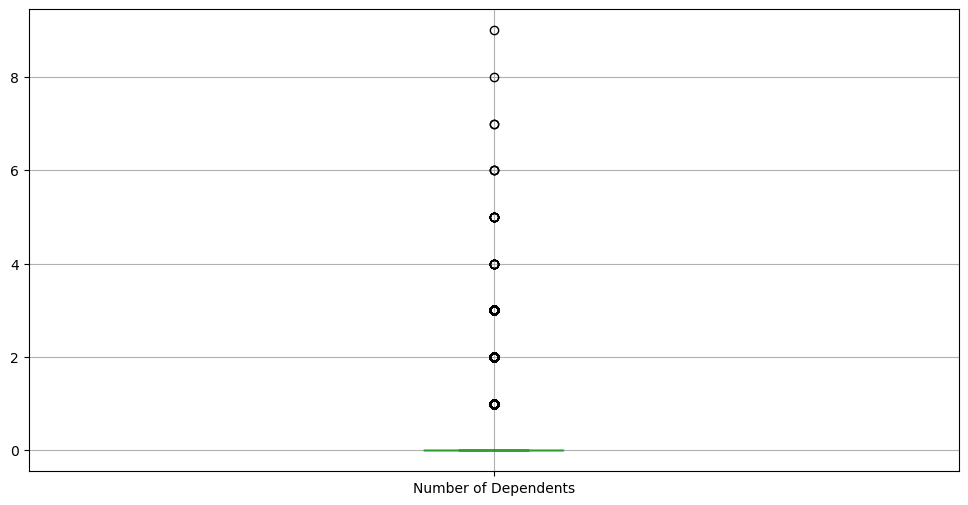

In [30]:
plt.figure(figsize=(12, 6)) 
boxplot = df.boxplot(column = ['Number of Dependents']) 
plt.show()

In [31]:
label_encoding = preprocessing.LabelEncoder()
df['Gender'] = label_encoding.fit_transform(df['Gender'])
df['Married'] = label_encoding.fit_transform(df['Married'])
df['Dependents'] = label_encoding.fit_transform(df['Dependents'])
df['Internet Service'] = label_encoding.fit_transform(df['Internet Service'])
df['Premium Tech Support'] = label_encoding.fit_transform(df['Premium Tech Support'])
df['Streaming Movies'] = label_encoding.fit_transform(df['Streaming Movies'])
df['Streaming Music'] = label_encoding.fit_transform(df['Streaming Music'])
df['Paperless Billing'] = label_encoding.fit_transform(df['Paperless Billing'])

In [32]:
data = ['Month-to-Month', 'One Year', 'Two Year']
df['Contract'] = df['Contract'].astype(str)

enc = OrdinalEncoder(categories=[data], handle_unknown='use_encoded_value', unknown_value=-1)

df['Contract'] = np.round(enc.fit_transform(df[['Contract']])).astype(int)

In [33]:
enc = OneHotEncoder()
a_prof_enc = pd.DataFrame(enc.fit_transform(df[['Internet Type']]).toarray(),columns=enc.get_feature_names_out())
b_prof_enc = pd.DataFrame(enc.fit_transform(df[['Payment Method']]).toarray(),columns=enc.get_feature_names_out())

df = df.reset_index()
df = df.reset_index()

df = pd.concat([df,a_prof_enc], axis=1)
df = pd.concat([df,b_prof_enc], axis=1)

In [34]:
df = df.drop(['Internet Type', 'Payment Method'], axis = 1)

In [35]:
df.head()

,level_0,index,Gender,Married,Dependents,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Internet Service,Avg Monthly GB Download,Premium Tech Support,Streaming Movies,Streaming Music,Contract,Paperless Billing,Monthly Charge,Total Refunds,Satisfaction Score,Age,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Service,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check
0,0,0,1,0,0,0,0,1,0.00,1,8,0,1,0,0,1,39.65,0.00,3,78,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1,1,0,1,1,1,1,8,48.85,1,17,0,0,0,0,1,80.65,0.00,3,74,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,2,2,1,0,1,3,0,18,11.33,1,52,0,1,1,0,1,95.45,45.61,2,71,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,3,3,0,1,1,1,1,25,19.76,1,12,0,1,0,0,1,98.50,13.43,2,78,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,4,4,0,1,1,1,1,37,6.33,1,14,0,0,0,0,1,76.50,0.00,2,80,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [36]:
df = df.drop(['level_0', 'index'], axis = 1)

In [37]:
df.head()

,Gender,Married,Dependents,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Internet Service,Avg Monthly GB Download,Premium Tech Support,Streaming Movies,Streaming Music,Contract,Paperless Billing,Monthly Charge,Total Refunds,Satisfaction Score,Age,Internet Type_Cable,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Service,Payment Method_Bank Withdrawal,Payment Method_Credit Card,Payment Method_Mailed Check
0,1,0,0,0,0,1,0.00,1,8,0,1,0,0,1,39.65,0.00,3,78,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,1,1,1,1,8,48.85,1,17,0,0,0,0,1,80.65,0.00,3,74,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1,0,1,3,0,18,11.33,1,52,0,1,1,0,1,95.45,45.61,2,71,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0,1,1,1,1,25,19.76,1,12,0,1,0,0,1,98.50,13.43,2,78,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0,1,1,1,1,37,6.33,1,14,0,0,0,0,1,76.50,0.00,2,80,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   int32  
 1   Married                            7043 non-null   int32  
 2   Dependents                         7043 non-null   int32  
 3   Number of Dependents               7043 non-null   int64  
 4   Number of Referrals                7043 non-null   int64  
 5   Tenure in Months                   7043 non-null   int64  
 6   Avg Monthly Long Distance Charges  7043 non-null   float64
 7   Internet Service                   7043 non-null   int32  
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Premium Tech Support               7043 non-null   int32  
 10  Streaming Movies                   7043 non-null   int32  
 11  Streaming Music                    7043 non-null   int32

In [39]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check'],
      dtype='object')

In [40]:
dfa = df[['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check']]

In [41]:
from sklearn.preprocessing import StandardScaler
x = dfa['Tenure in Months']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Tenure in Months'] = std_scaler.transform(x)

In [42]:
x = dfa['Avg Monthly GB Download']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Avg Monthly GB Download'] = std_scaler.transform(x)

In [43]:
x = dfa['Age']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Age'] = std_scaler.transform(x)

In [44]:
x = dfa['Avg Monthly Long Distance Charges']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Avg Monthly Long Distance Charges'] = std_scaler.transform(x)

In [45]:
x = dfa['Total Refunds']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Total Refunds'] = std_scaler.transform(x)

In [46]:
x = dfa['Monthly Charge']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Monthly Charge'] = std_scaler.transform(x)

In [47]:
x = dfa['Number of Referrals']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Number of Referrals'] = std_scaler.transform(x)

In [48]:
x = dfa['Satisfaction Score']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Satisfaction Score'] = std_scaler.transform(x)

In [49]:
x = dfa['Number of Dependents']
x = (np.array(x)).reshape(-1,1)
std_scaler = StandardScaler()
std_scaler.fit(x)

dfa['Number of Dependents'] = std_scaler.transform(x)

In [50]:
distortions = []
silhouette_scores = []
K = range(2, 10)
for k in K:
    kmeanModel = KMeans(n_clusters = k, n_init = 10)
    cluster_labels = kmeanModel.fit_predict(dfa)

    silhouette_avg = silhouette_score(dfa, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    distortions.append(kmeanModel.inertia_)
    
    print(f"For n_clusters = {k}, Silhouette Score = {silhouette_avg:.4f}")

For n_clusters = 2, Silhouette Score = 0.1421
For n_clusters = 3, Silhouette Score = 0.1427
For n_clusters = 4, Silhouette Score = 0.1359
For n_clusters = 5, Silhouette Score = 0.1510
For n_clusters = 6, Silhouette Score = 0.1483
For n_clusters = 7, Silhouette Score = 0.1337
For n_clusters = 8, Silhouette Score = 0.1325
For n_clusters = 9, Silhouette Score = 0.1302


In [51]:
dfb = df[['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check']]

In [52]:
from sklearn.preprocessing import MinMaxScaler

x = dfb['Tenure in Months']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Tenure in Months'] = min_max_scaler.transform(x)

In [53]:
x = dfb['Avg Monthly GB Download']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Avg Monthly GB Download'] = min_max_scaler.transform(x)

In [54]:
x = dfb['Age']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Age'] = min_max_scaler.transform(x)

In [55]:
x = dfb['Avg Monthly Long Distance Charges']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Avg Monthly Long Distance Charges'] = min_max_scaler.transform(x)

In [56]:
x = dfb['Total Refunds']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Total Refunds'] = min_max_scaler.transform(x)

In [57]:
x = dfb['Monthly Charge']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Monthly Charge'] = min_max_scaler.transform(x)

In [58]:
x = dfb['Number of Referrals']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Number of Referrals'] = min_max_scaler.transform(x)

In [59]:
x = dfb['Satisfaction Score']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Satisfaction Score'] = min_max_scaler.transform(x)

In [60]:
x = dfb['Number of Dependents']
x = (np.array(x)).reshape(-1,1)
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(x)
dfb['Number of Dependents'] = min_max_scaler.transform(x)

In [61]:
distortions = []
silhouette_scores = []
K = range(2, 10)
for k in K:
    kmeanModel = KMeans(n_clusters = k, n_init = 10)
    cluster_labels = kmeanModel.fit_predict(dfb)

    silhouette_avg = silhouette_score(dfb, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    distortions.append(kmeanModel.inertia_)
    
    print(f"For n_clusters = {k}, Silhouette Score = {silhouette_avg:.4f}")

For n_clusters = 2, Silhouette Score = 0.1673
For n_clusters = 3, Silhouette Score = 0.1899
For n_clusters = 4, Silhouette Score = 0.1684
For n_clusters = 5, Silhouette Score = 0.1538
For n_clusters = 6, Silhouette Score = 0.1439
For n_clusters = 7, Silhouette Score = 0.1464
For n_clusters = 8, Silhouette Score = 0.1462
For n_clusters = 9, Silhouette Score = 0.1443


In [62]:
df1 = df[['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check']]

In [63]:
x = df1['Number of Dependents']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Number of Dependents'] = rob_scaler.transform(x)

In [64]:
x = df1['Number of Referrals']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Number of Referrals'] = rob_scaler.transform(x)

In [65]:
x = df1['Tenure in Months']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Tenure in Months'] = rob_scaler.transform(x)

In [66]:
x = df1['Avg Monthly Long Distance Charges']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Avg Monthly Long Distance Charges'] = rob_scaler.transform(x)

In [67]:
x = df1['Avg Monthly GB Download']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Avg Monthly GB Download'] = rob_scaler.transform(x)

In [68]:
x = df1['Monthly Charge']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Monthly Charge'] = rob_scaler.transform(x)

In [69]:
x = df1['Total Refunds']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Total Refunds'] = rob_scaler.transform(x)

In [70]:
x = df1['Satisfaction Score']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Satisfaction Score'] = rob_scaler.transform(x)

In [71]:
x = df1['Age']
x = (np.array(x)).reshape(-1,1)
rob_scaler = RobustScaler()
rob_scaler.fit(x)

df1['Age'] = rob_scaler.transform(x)

In [72]:
distortions = []
silhouette_scores = []
K = range(2, 10)
for k in K:
    kmeanModel = KMeans(n_clusters = k, n_init = 10)
    cluster_labels = kmeanModel.fit_predict(df1)

    silhouette_avg = silhouette_score(df1, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    distortions.append(kmeanModel.inertia_)
    
    print(f"For n_clusters = {k}, Silhouette Score = {silhouette_avg:.4f}")

For n_clusters = 2, Silhouette Score = 0.8485
For n_clusters = 3, Silhouette Score = 0.7821
For n_clusters = 4, Silhouette Score = 0.1587
For n_clusters = 5, Silhouette Score = 0.1568
For n_clusters = 6, Silhouette Score = 0.1566
For n_clusters = 7, Silhouette Score = 0.1595
For n_clusters = 8, Silhouette Score = 0.1589
For n_clusters = 9, Silhouette Score = 0.1604


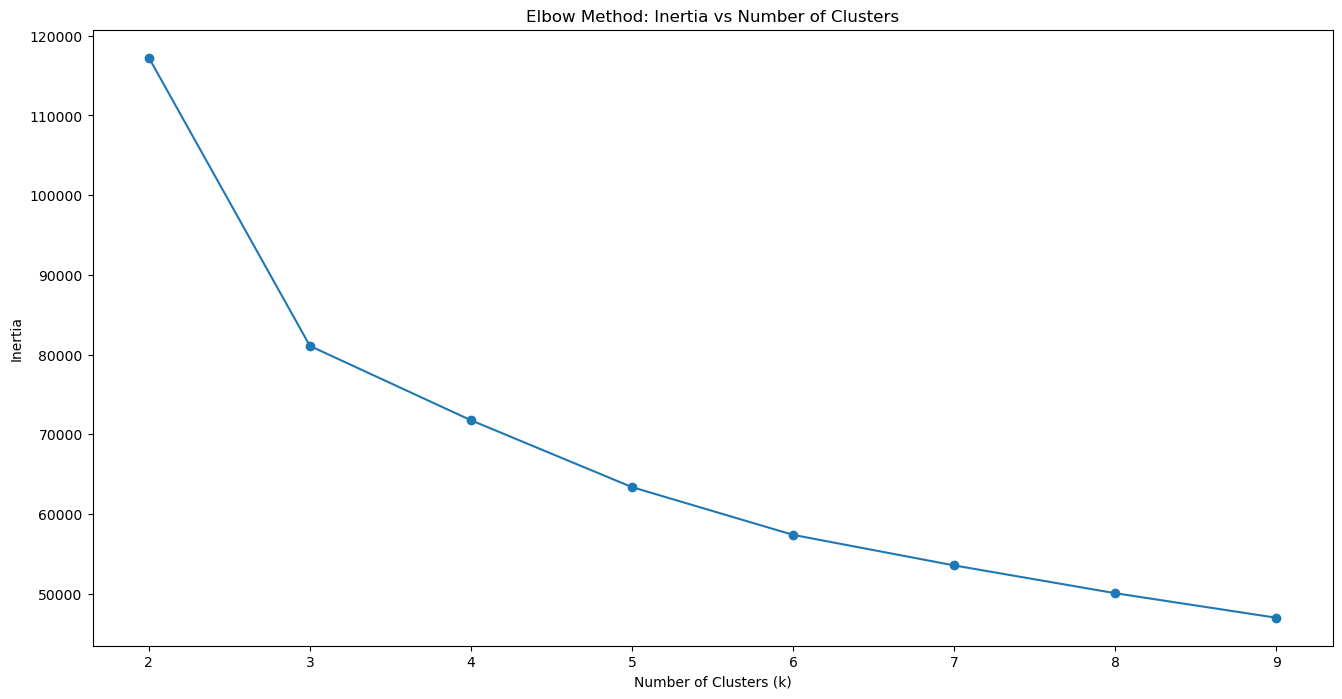

In [73]:
plt.figure(figsize = (16, 8))
plt.plot(K, distortions, marker = 'o', label = 'Inertia (Distortion)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Inertia vs Number of Clusters')
plt.show()

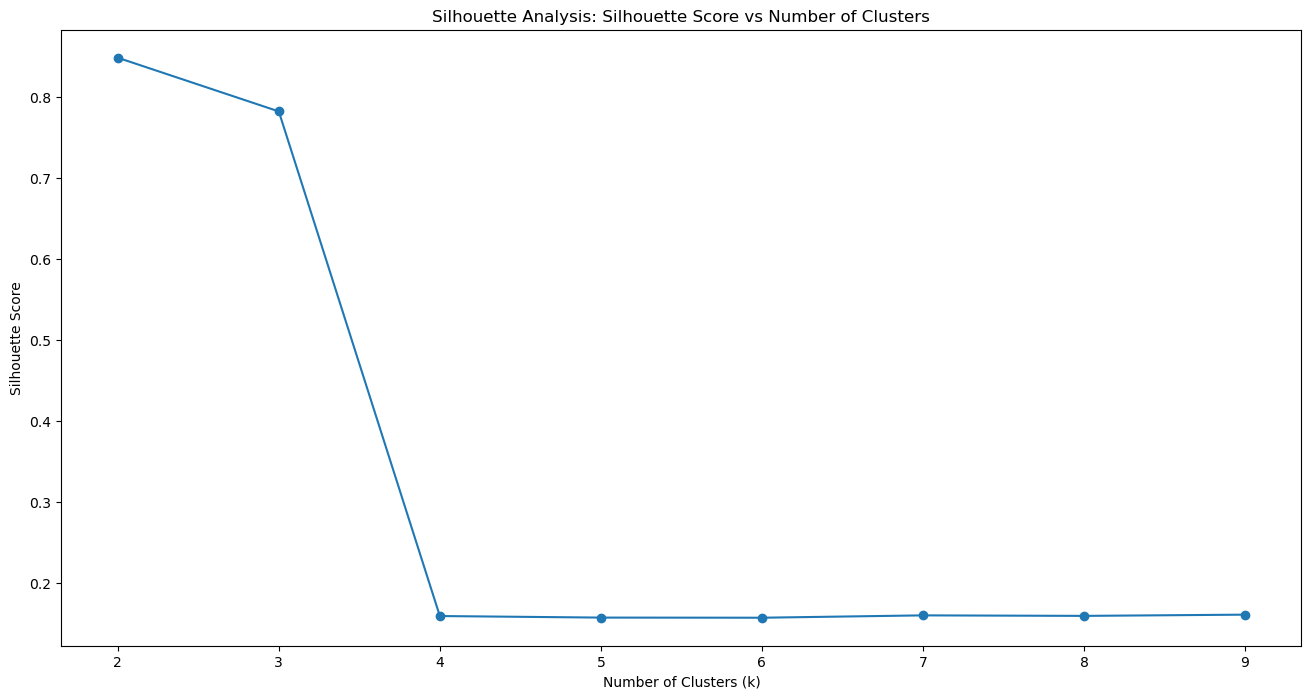

In [74]:
plt.figure(figsize=(16, 8))
plt.plot(K, silhouette_scores, marker = 'o', label = 'Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis: Silhouette Score vs Number of Clusters')
plt.show()

In [75]:
kmeanModel = KMeans(n_clusters = 2, n_init = 10)
kmeanModel.fit(df1)

KMeans(n_clusters=2, n_init=10)

In [76]:
df1['k_means'] = kmeanModel.predict(df1)

In [77]:
df1['k_means'].value_counts()

k_means
0    6667
1     376
Name: count, dtype: int64

In [78]:
kmeanModel = KMeans(n_clusters = 3, n_init = 10)
kmeanModel.fit(df1)

KMeans(n_clusters=3, n_init=10)

In [79]:
df1['k_means'] = kmeanModel.predict(df1)

In [80]:
df1['k_means'].value_counts()

k_means
0    6604
2     233
1     206
Name: count, dtype: int64

In [81]:
cluster_1 = df1[df1['k_means'] == 0]

In [82]:
cluster_2 = df1[df1['k_means'] == 1]

In [83]:
cluster_1.columns

Index(['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'k_means'],
      dtype='object')

In [84]:
num_fea = cluster_1[['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check']]

Gender
Skew : -0.02


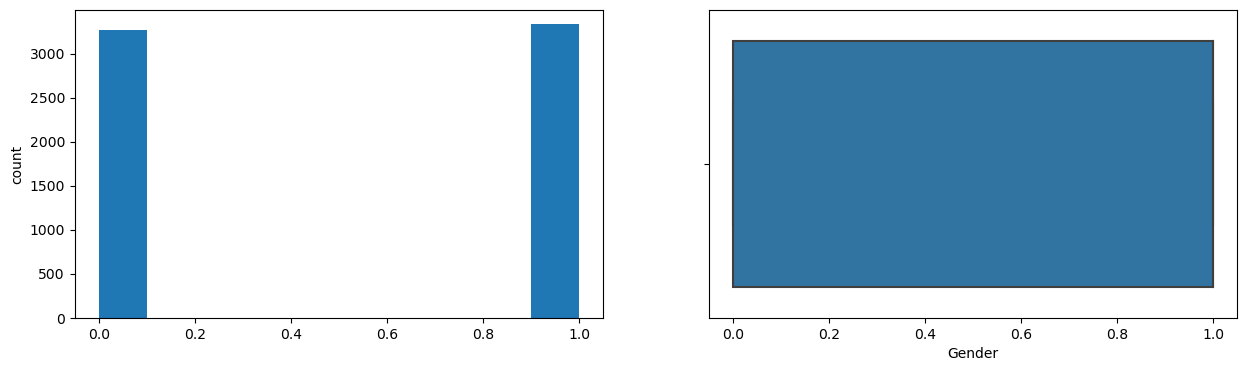

Married
Skew : 0.09


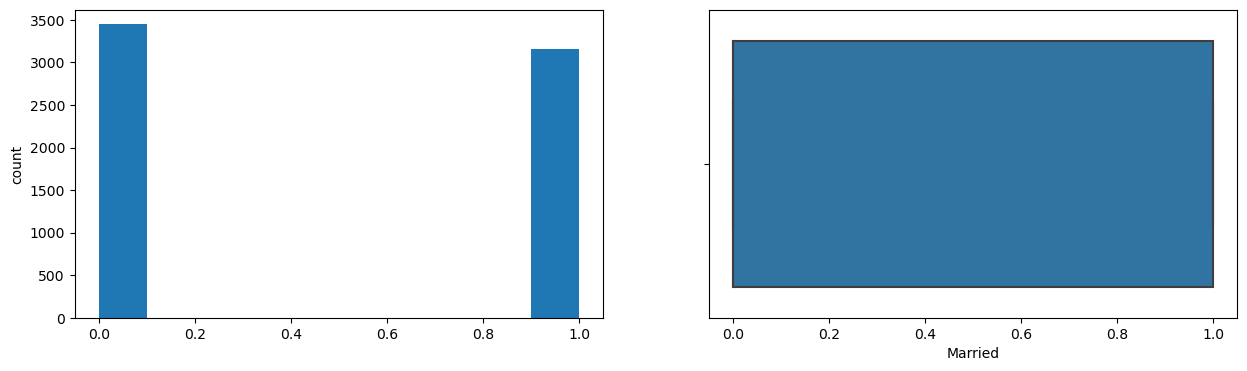

Dependents
Skew : 1.29


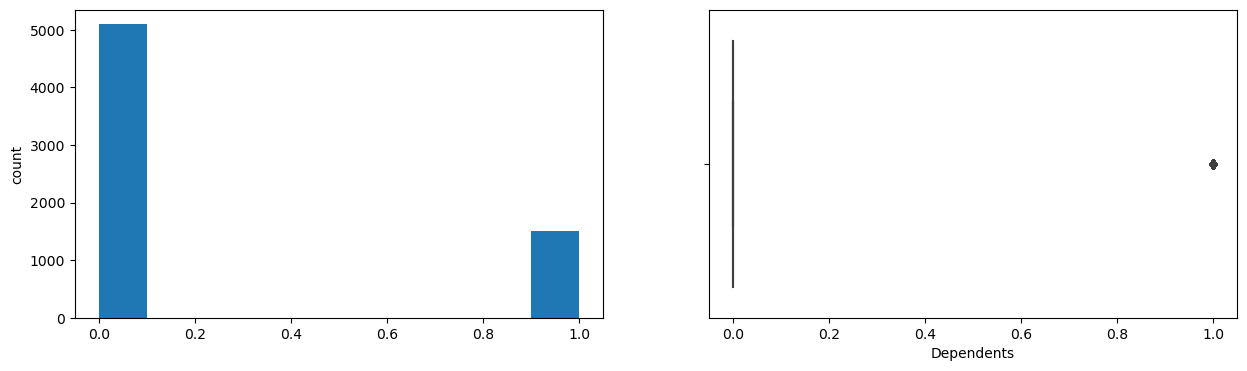

Number of Dependents
Skew : 2.13


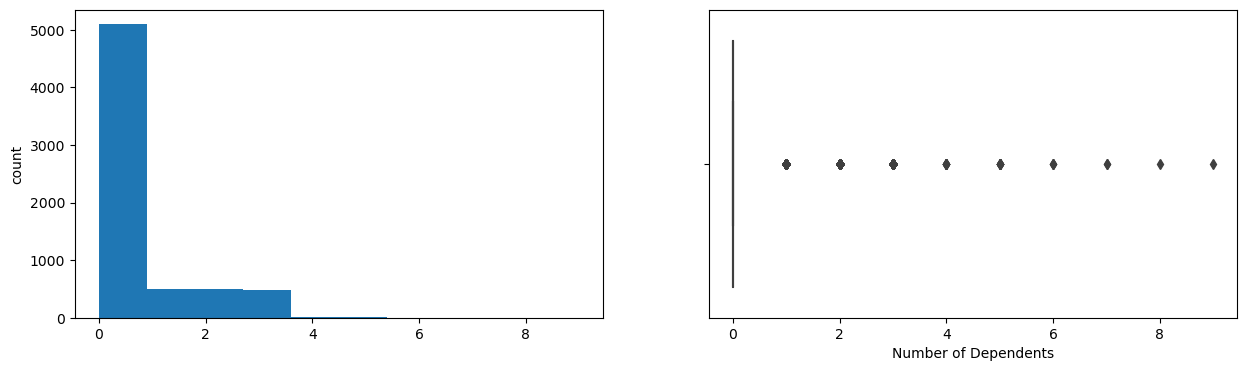

Number of Referrals
Skew : 1.46


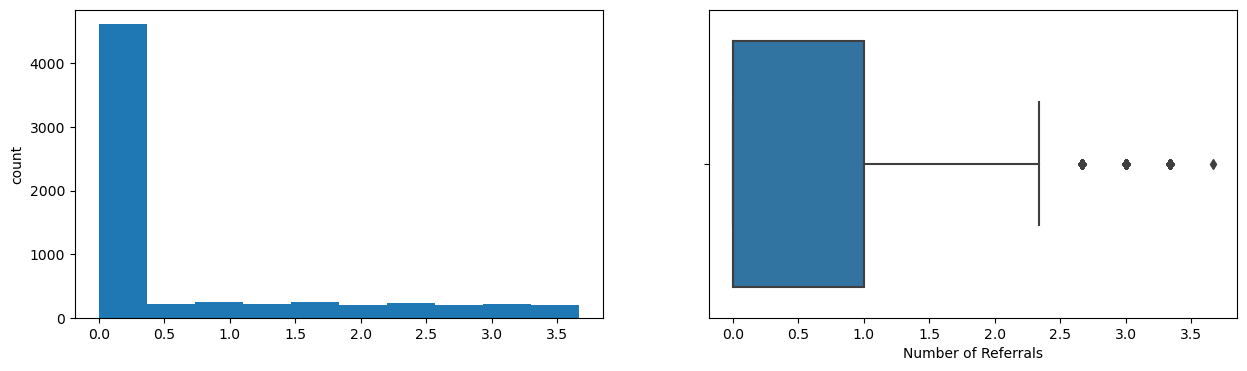

Tenure in Months
Skew : 0.26


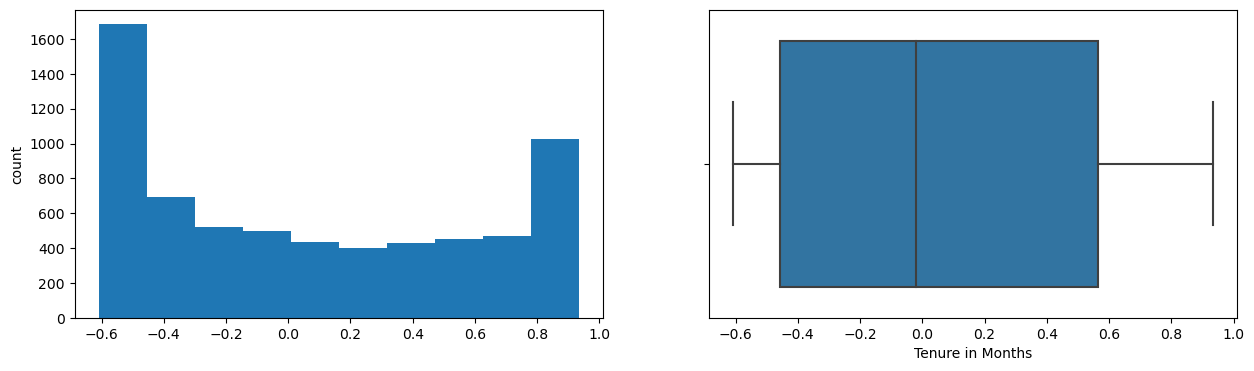

Avg Monthly Long Distance Charges
Skew : 0.04


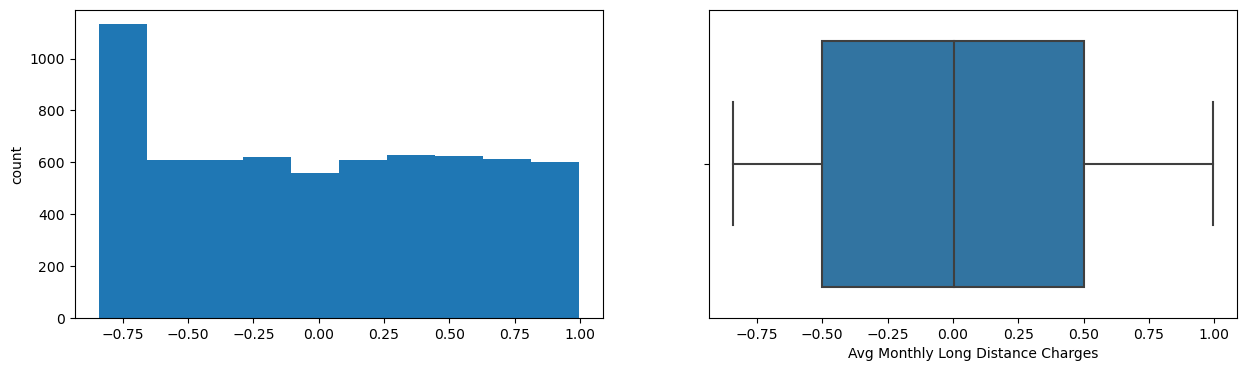

Internet Service
Skew : -1.36


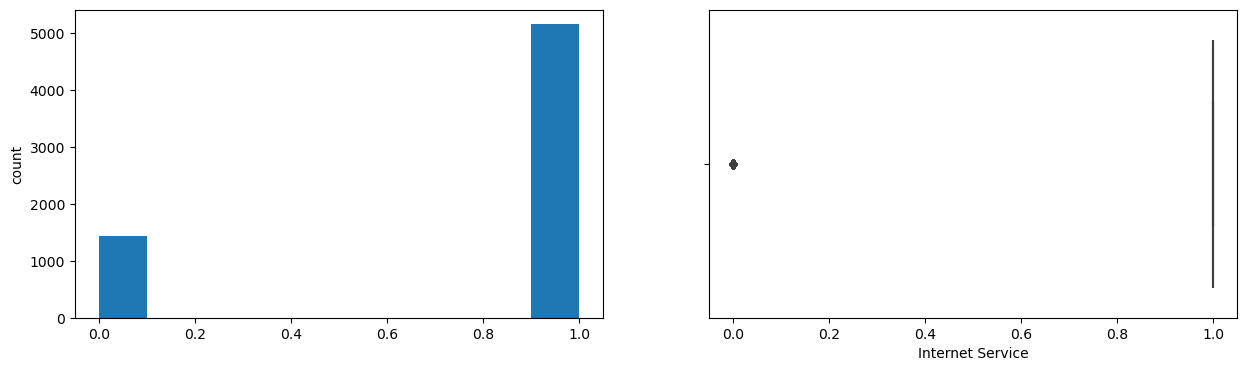

Avg Monthly GB Download
Skew : 1.22


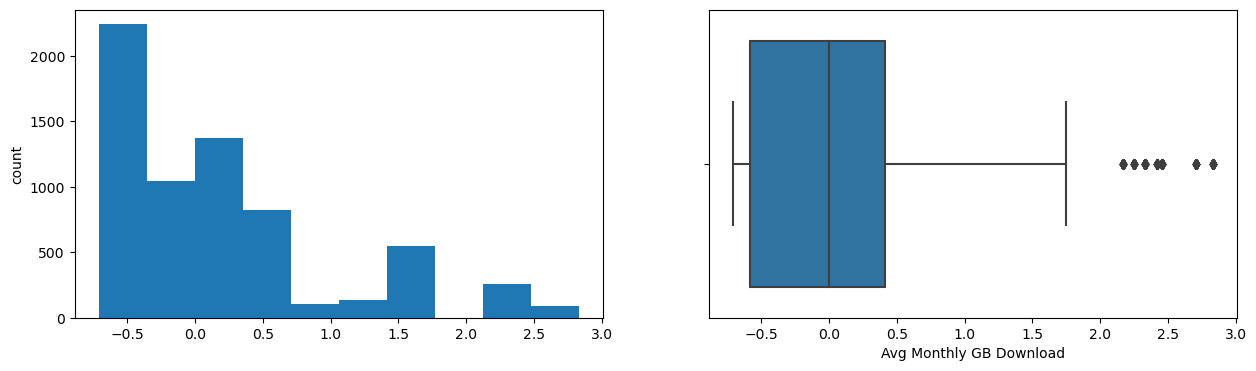

Premium Tech Support
Skew : 0.94


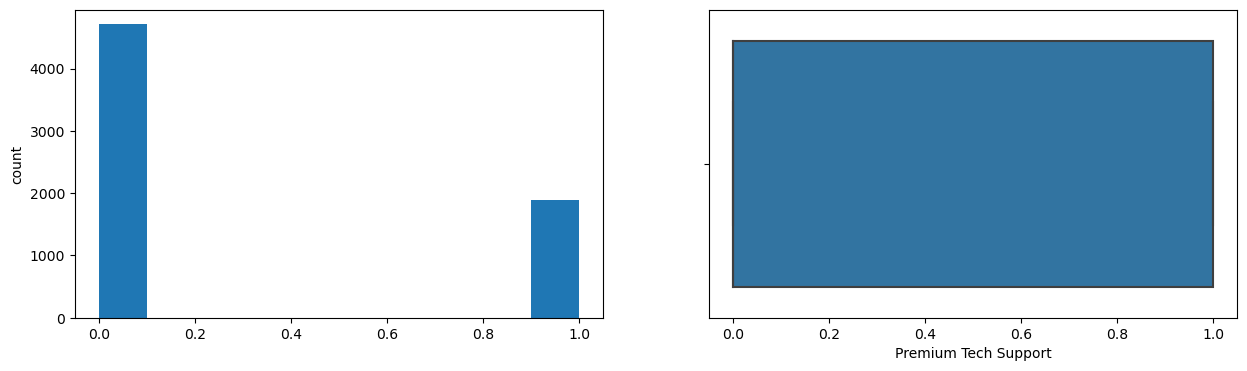

Streaming Movies
Skew : 0.46


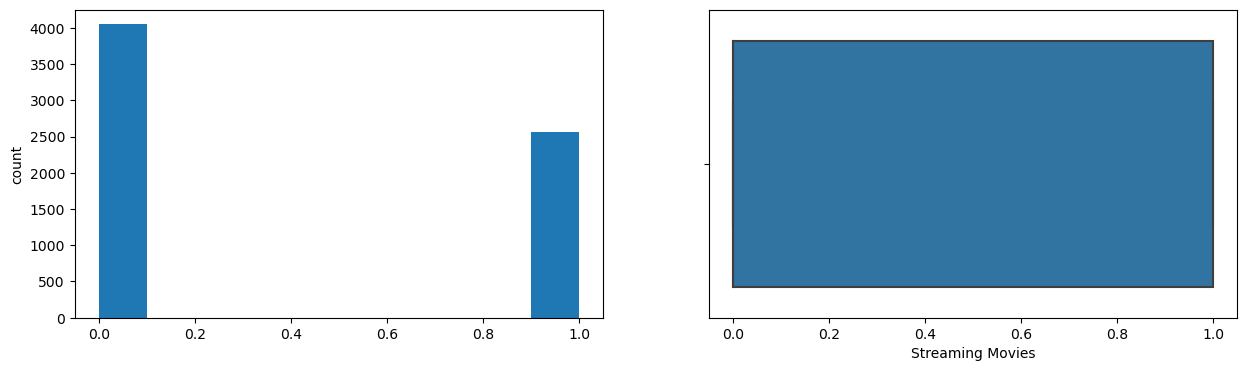

Streaming Music
Skew : 0.61


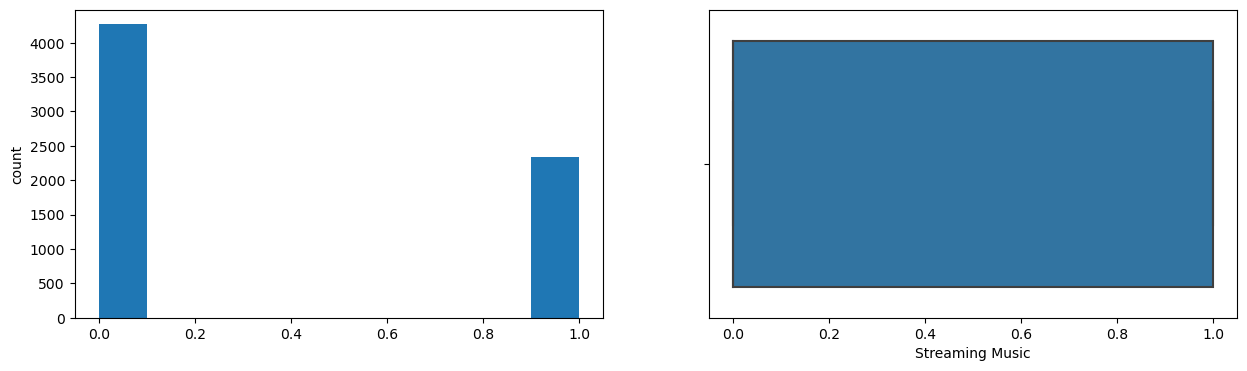

Contract
Skew : 0.51


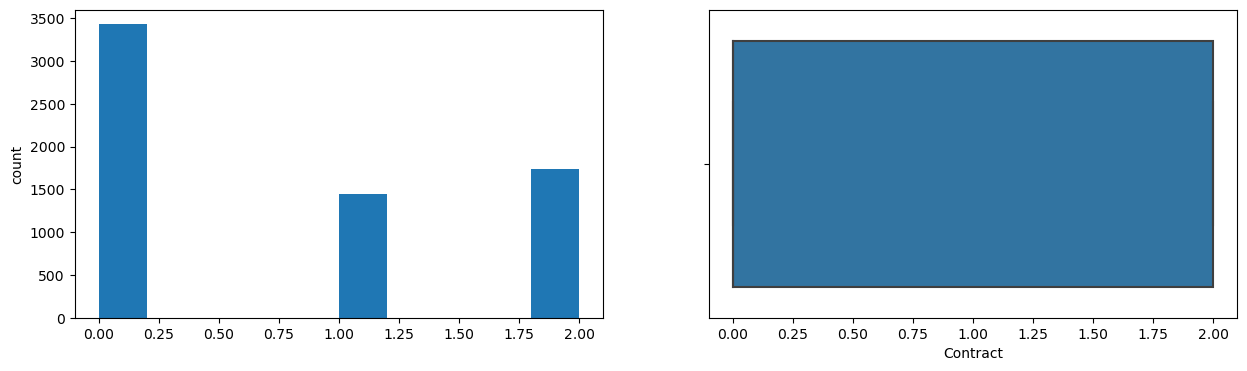

Paperless Billing
Skew : -0.38


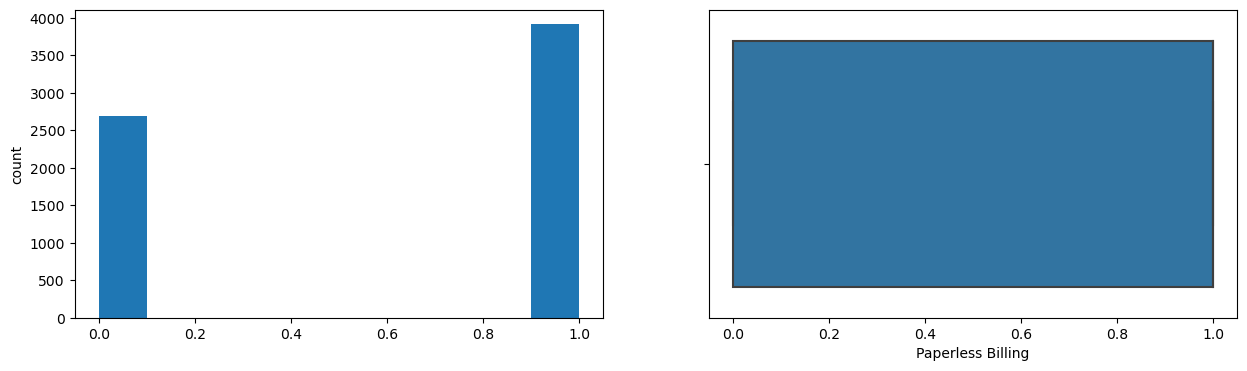

Monthly Charge
Skew : -0.21


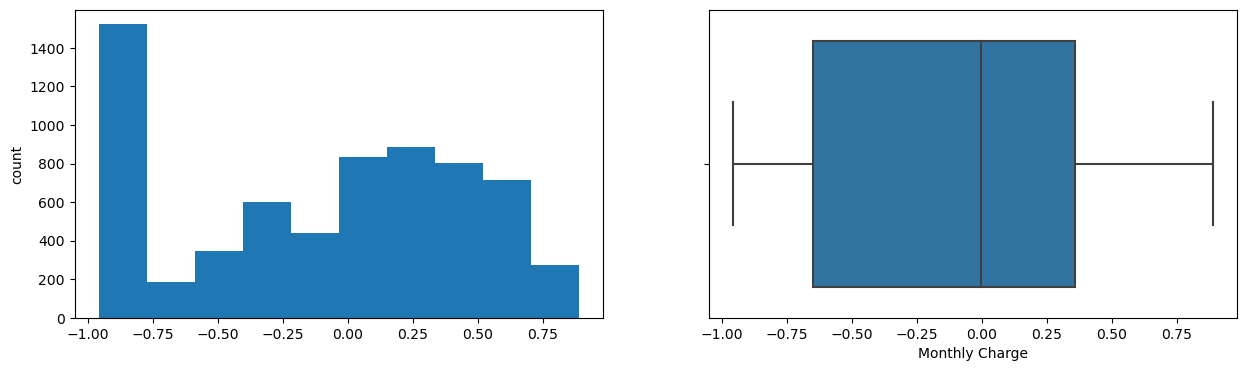

Total Refunds
Skew : 11.02


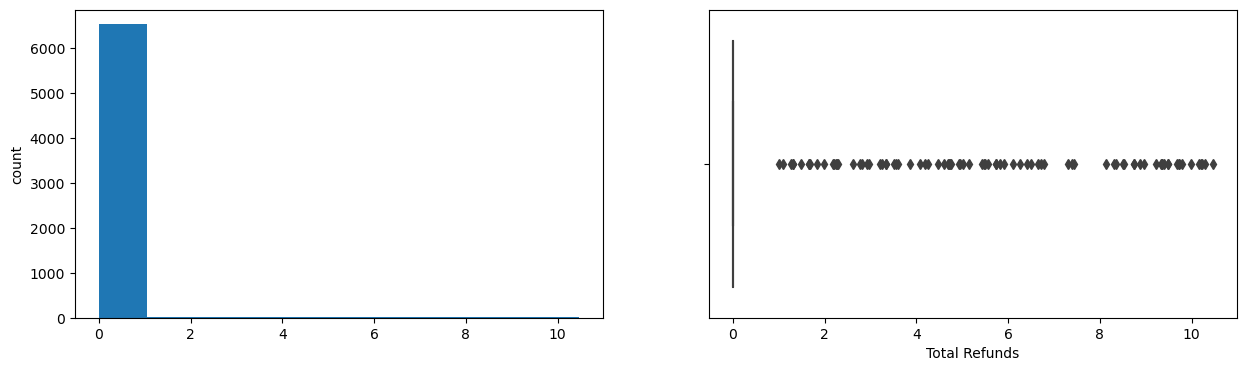

Satisfaction Score
Skew : -0.36


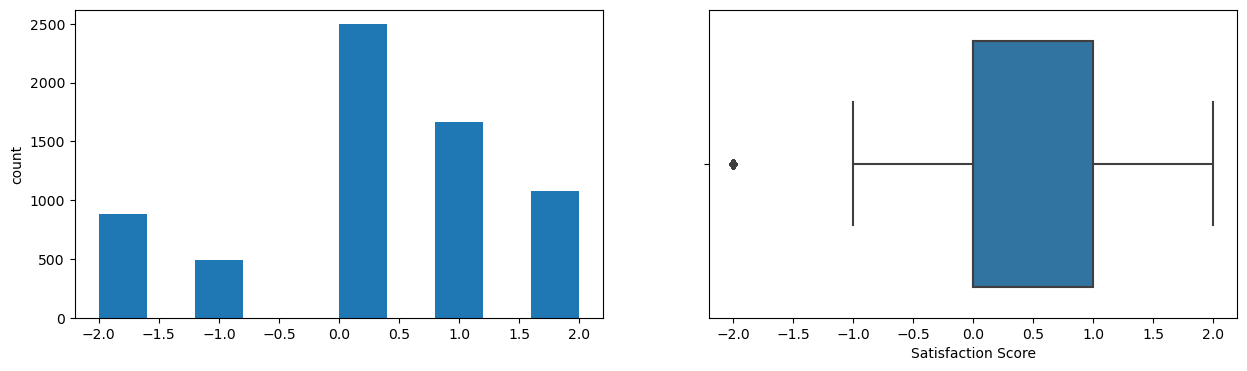

Age
Skew : 0.16


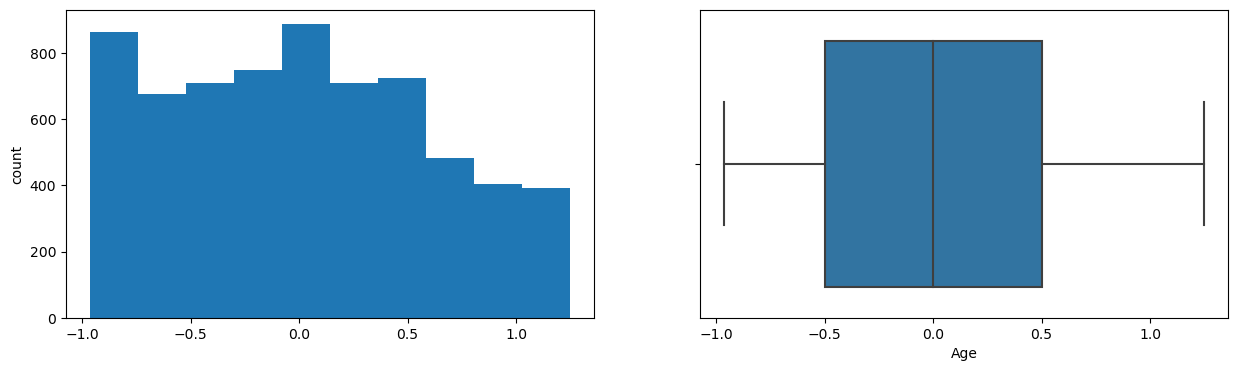

Internet Type_Cable
Skew : 2.35


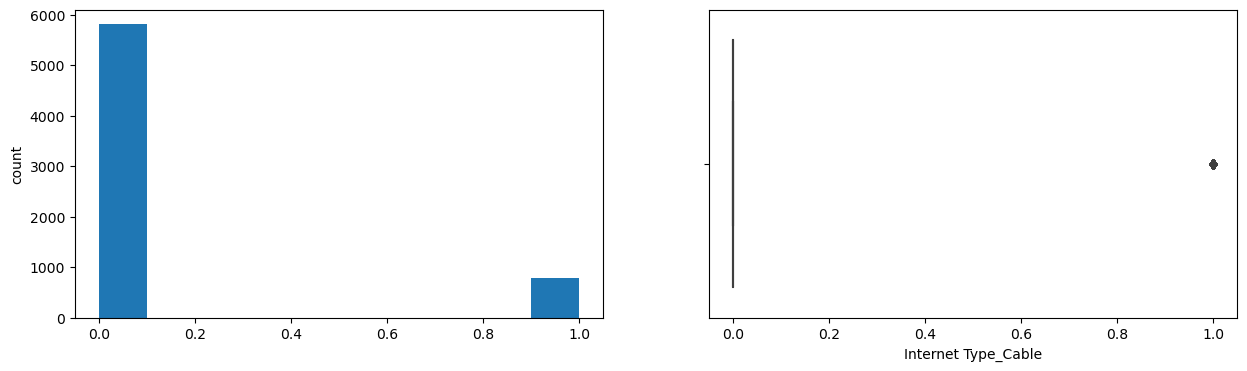

Internet Type_DSL
Skew : 1.26


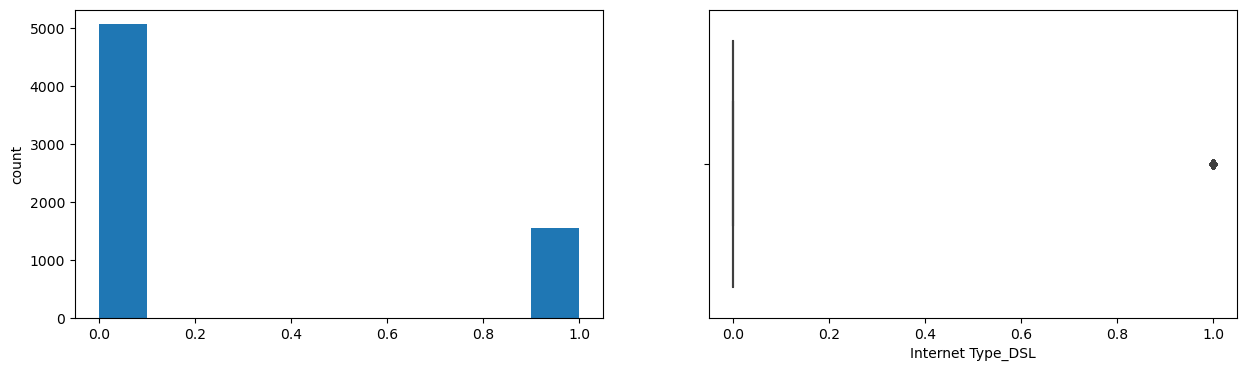

Internet Type_Fiber Optic
Skew : 0.29


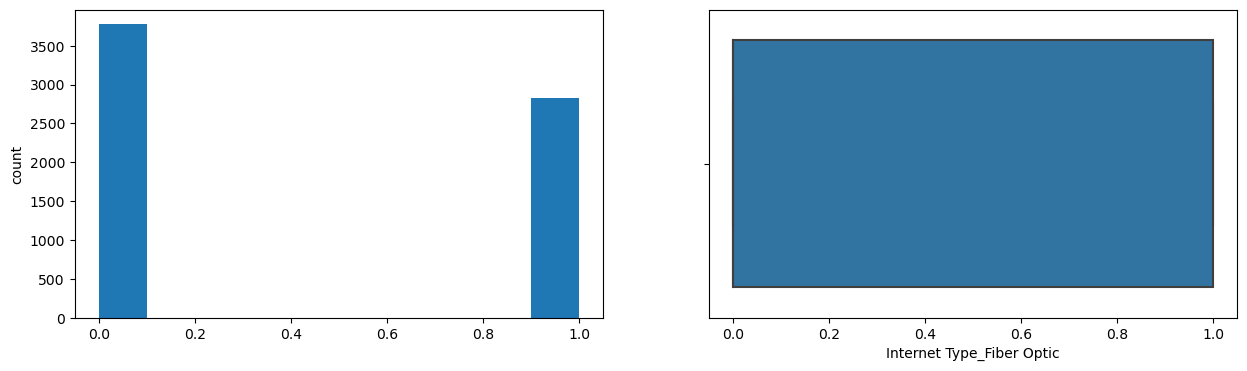

Internet Type_No Service
Skew : 1.36


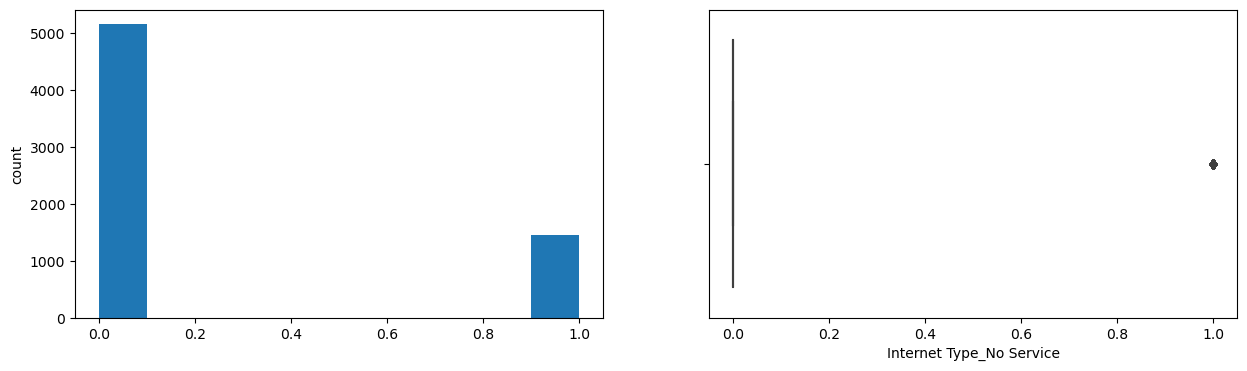

Payment Method_Bank Withdrawal
Skew : -0.21


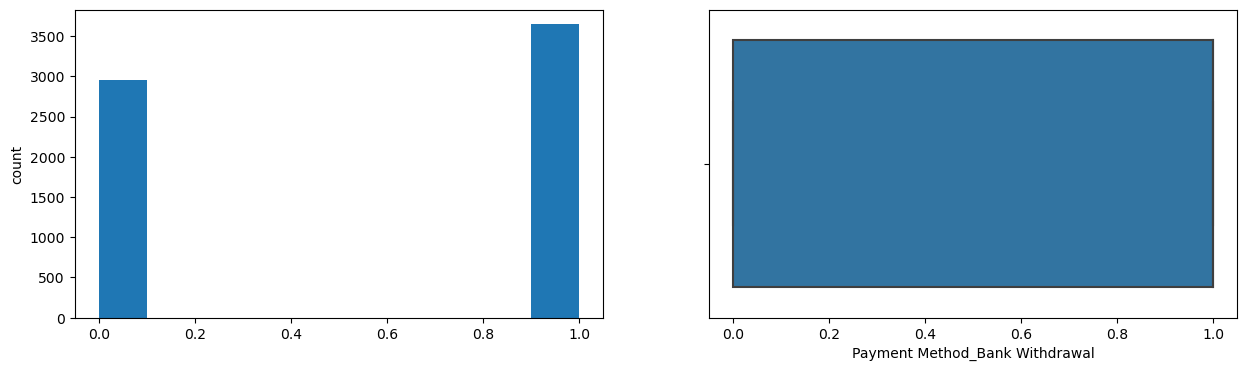

Payment Method_Credit Card
Skew : 0.44


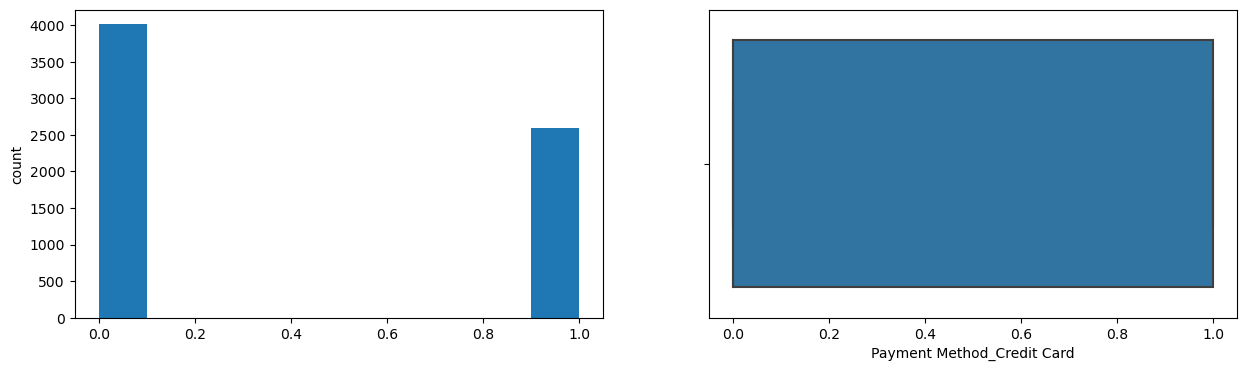

Payment Method_Mailed Check
Skew : 3.87


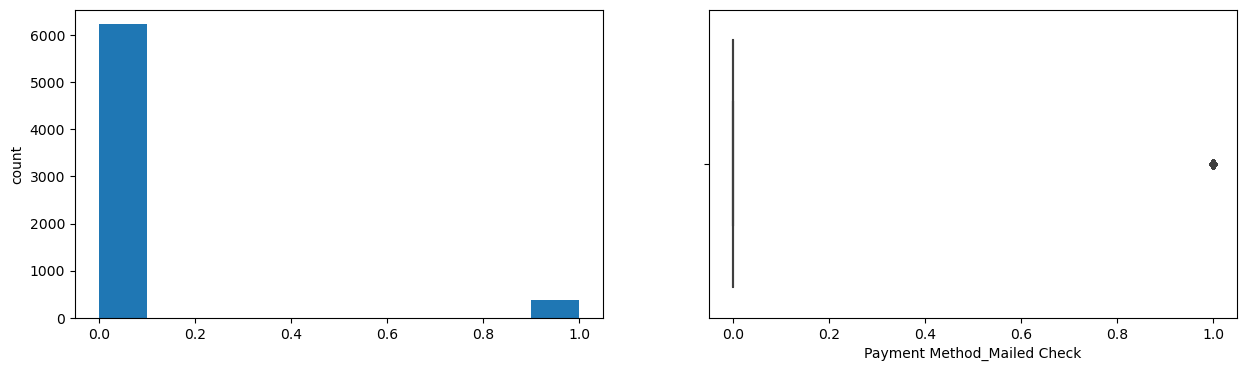

In [85]:
import seaborn as sns
for col in num_fea:
    print(col)
    print('Skew :', round(cluster_1[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    cluster_1[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x = cluster_1[col])
    plt.show()

In [86]:
cluster_2.columns

Index(['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check', 'k_means'],
      dtype='object')

In [87]:
num_fea1 = cluster_2[['Gender', 'Married', 'Dependents', 'Number of Dependents',
       'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Internet Service',
       'Avg Monthly GB Download', 'Premium Tech Support', 'Streaming Movies',
       'Streaming Music', 'Contract', 'Paperless Billing', 'Monthly Charge',
       'Total Refunds', 'Satisfaction Score', 'Age', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Service', 'Payment Method_Bank Withdrawal',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check']]

Gender
Skew : -0.08


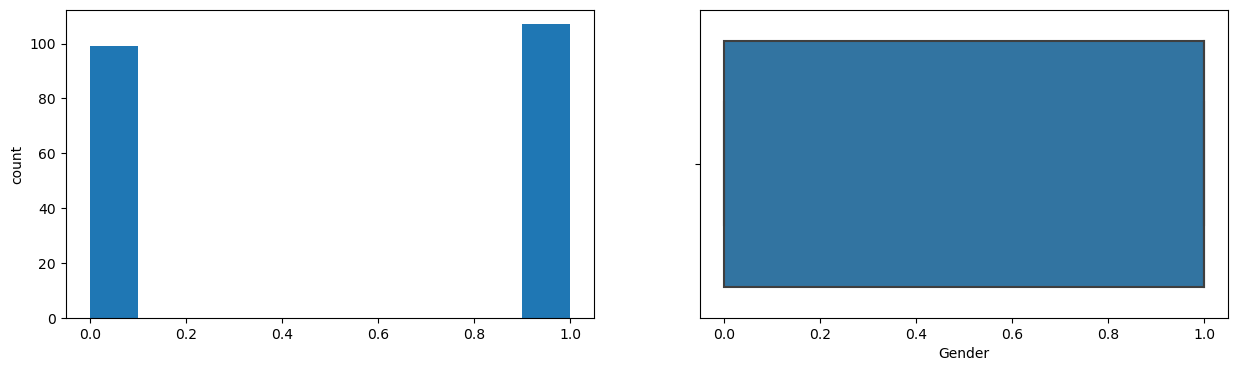

Married
Skew : -0.34


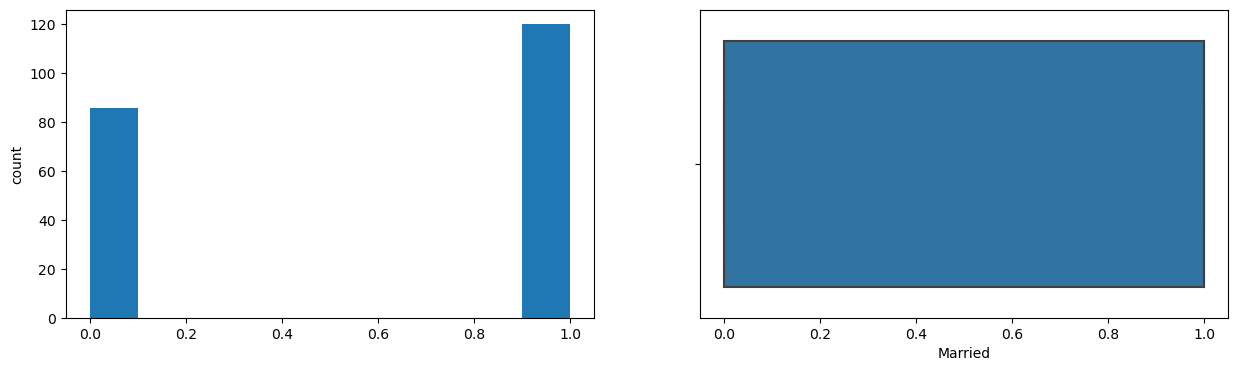

Dependents
Skew : 1.01


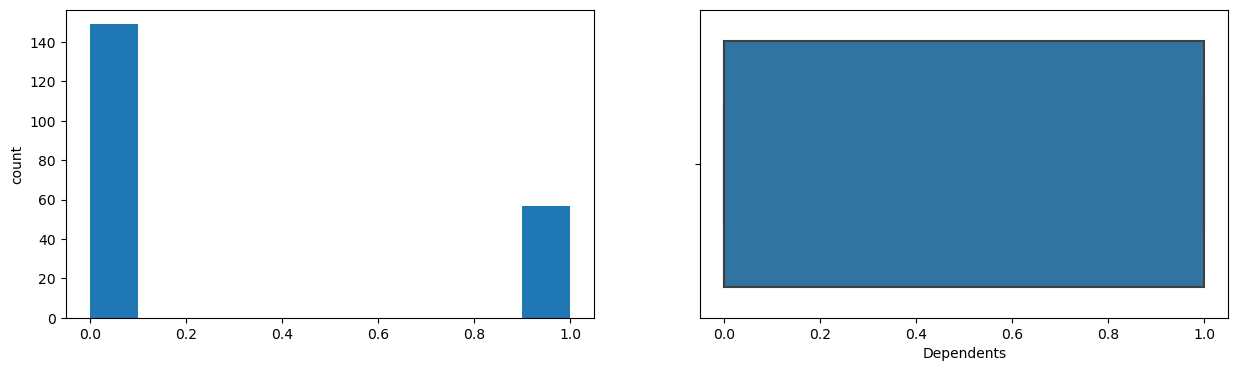

Number of Dependents
Skew : 1.57


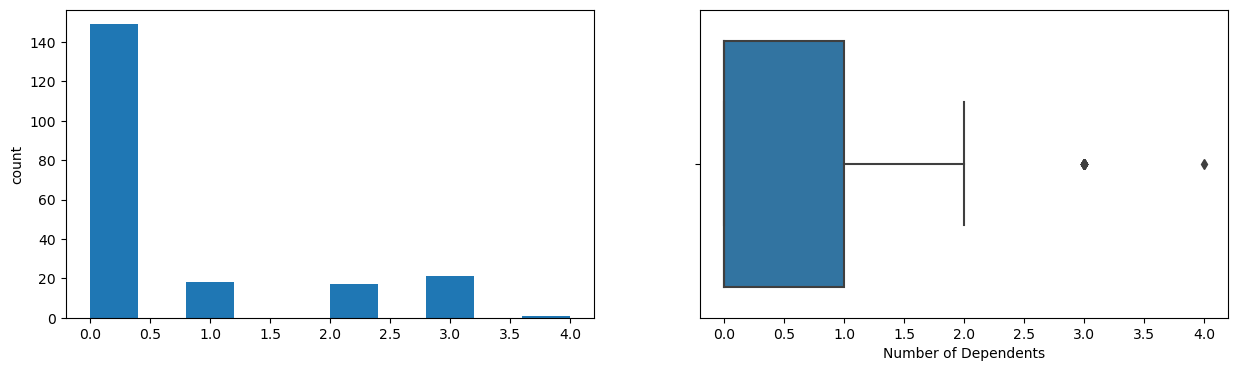

Number of Referrals
Skew : 1.21


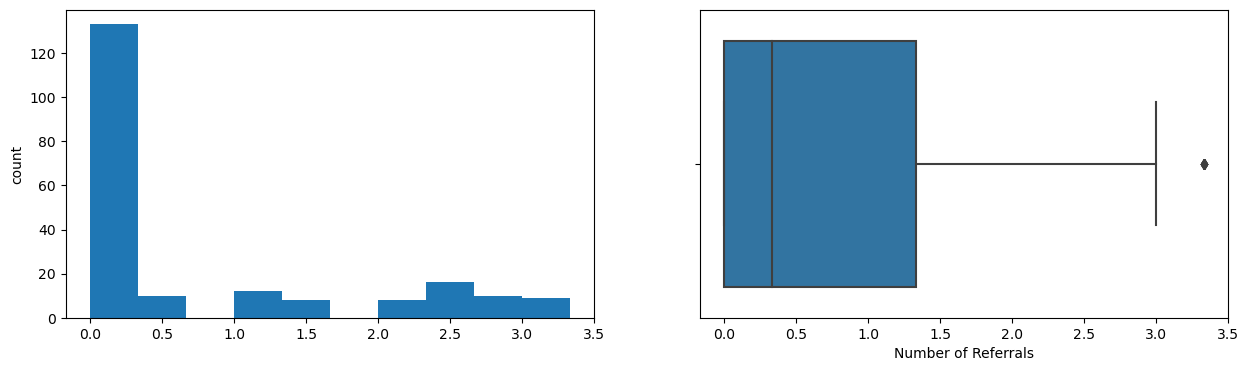

Tenure in Months
Skew : 0.09


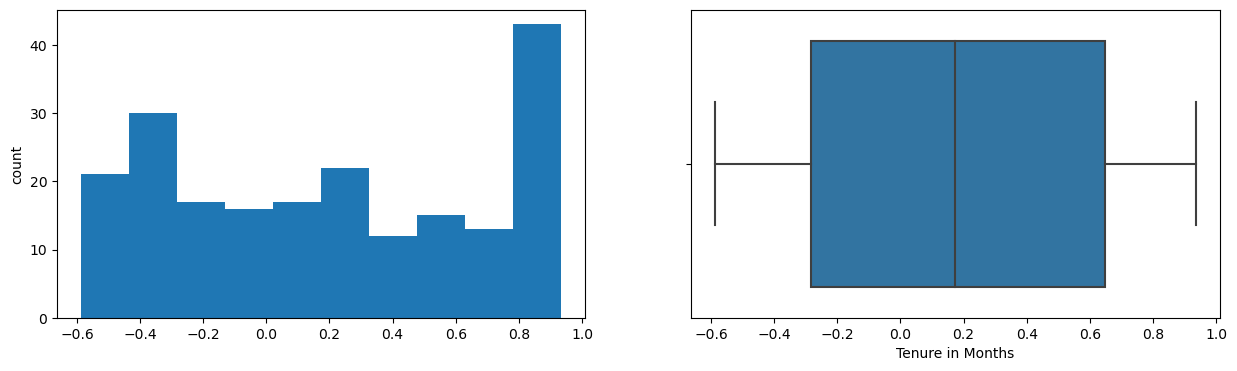

Avg Monthly Long Distance Charges
Skew : 0.22


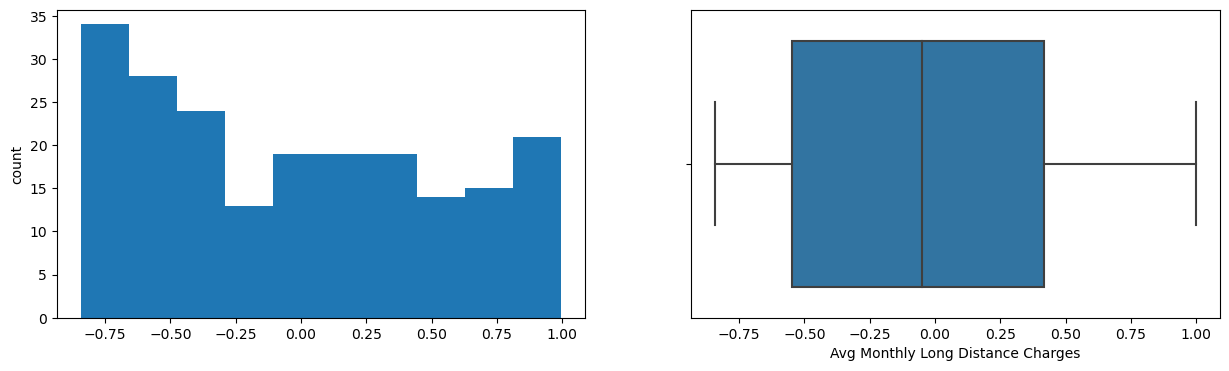

Internet Service
Skew : -1.77


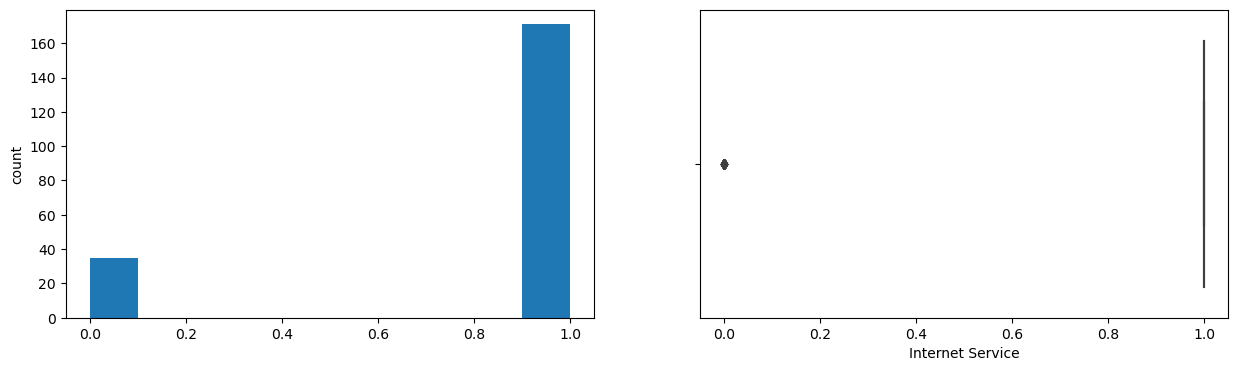

Avg Monthly GB Download
Skew : 1.06


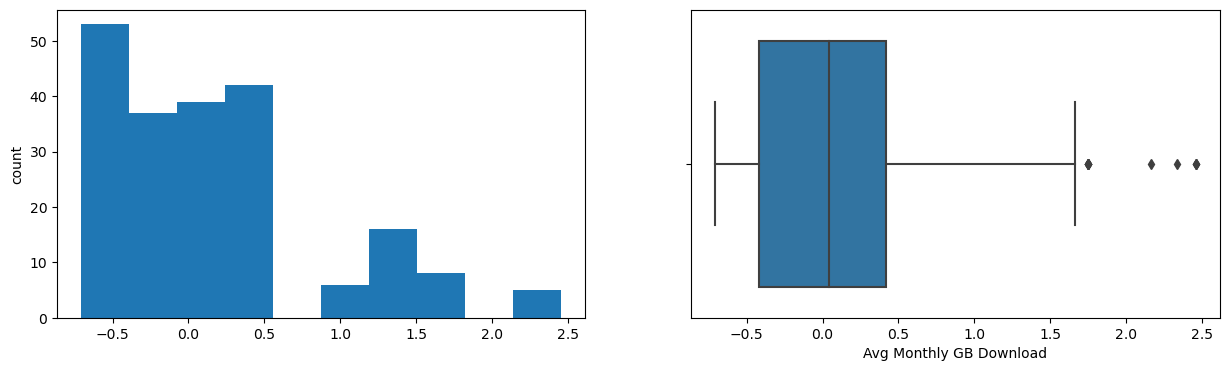

Premium Tech Support
Skew : 0.59


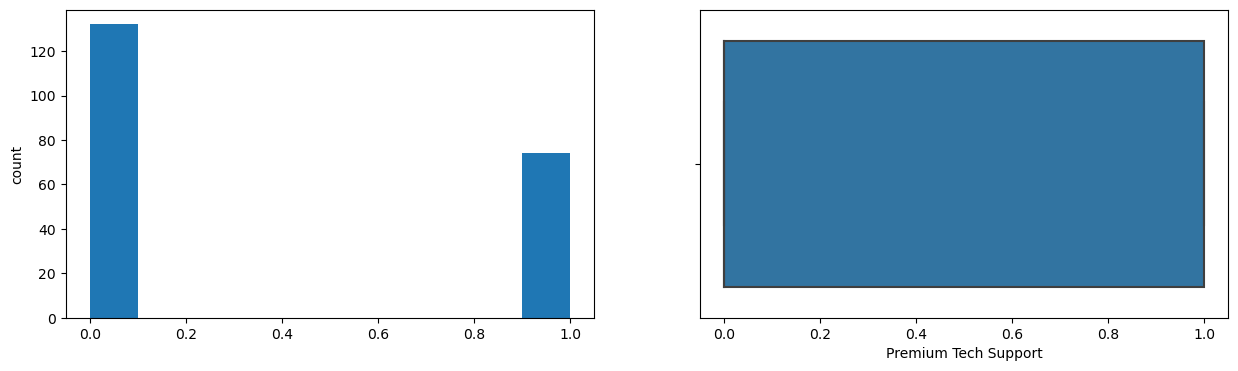

Streaming Movies
Skew : 0.26


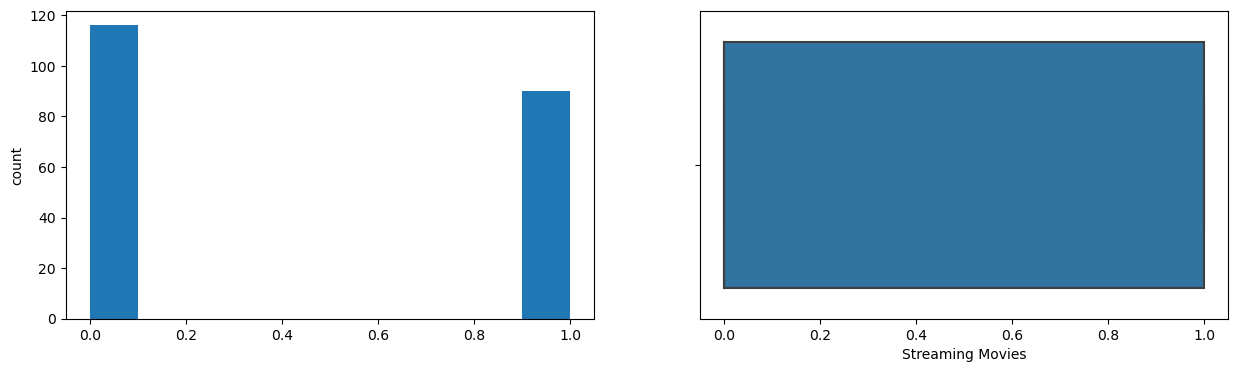

Streaming Music
Skew : 0.5


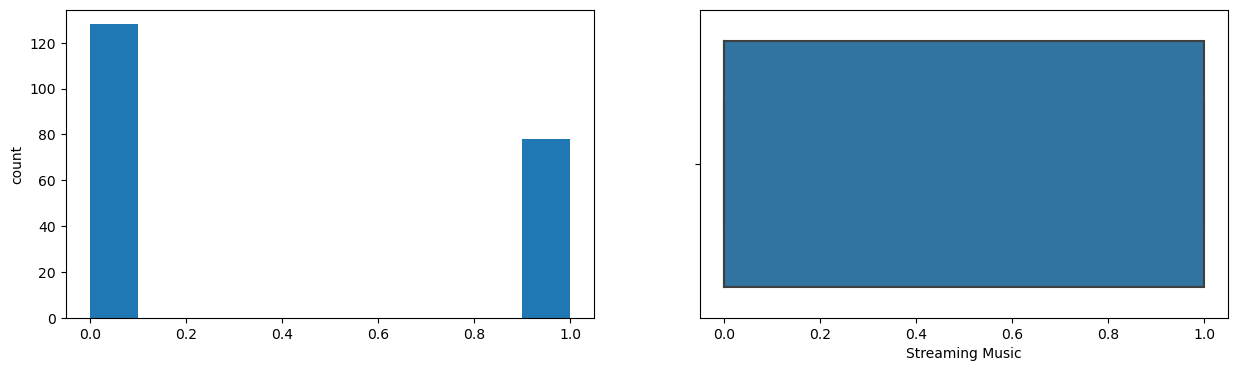

Contract
Skew : 0.19


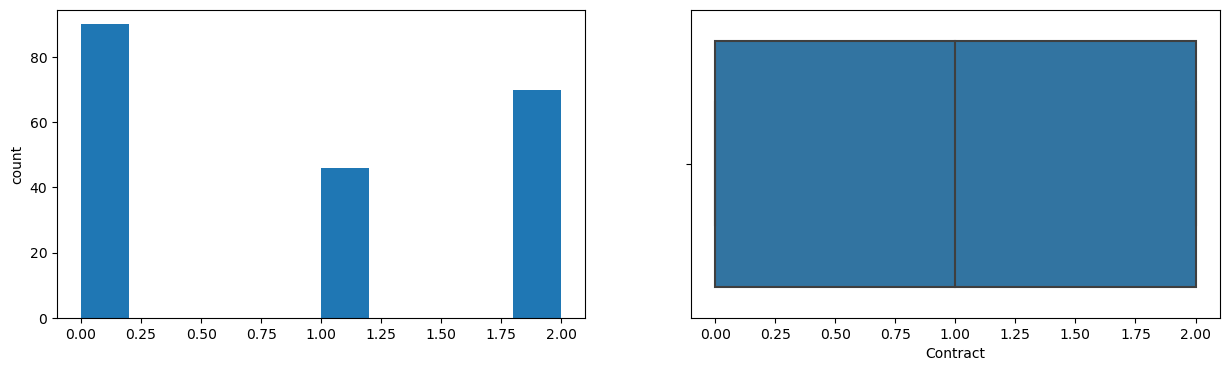

Paperless Billing
Skew : -0.46


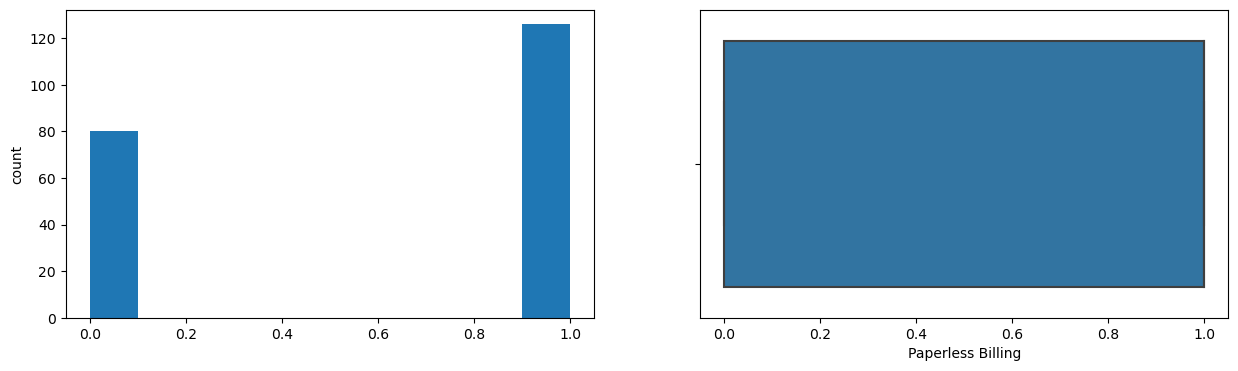

Monthly Charge
Skew : -0.44


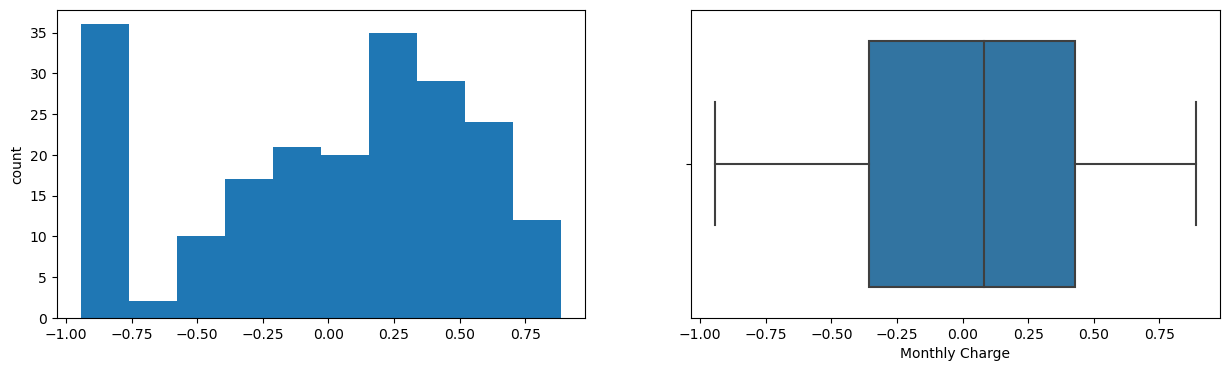

Total Refunds
Skew : -0.08


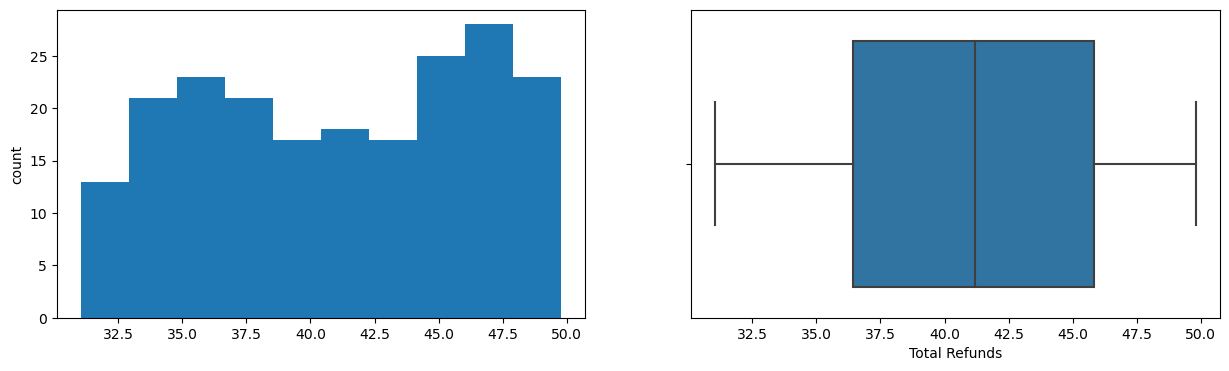

Satisfaction Score
Skew : -0.48


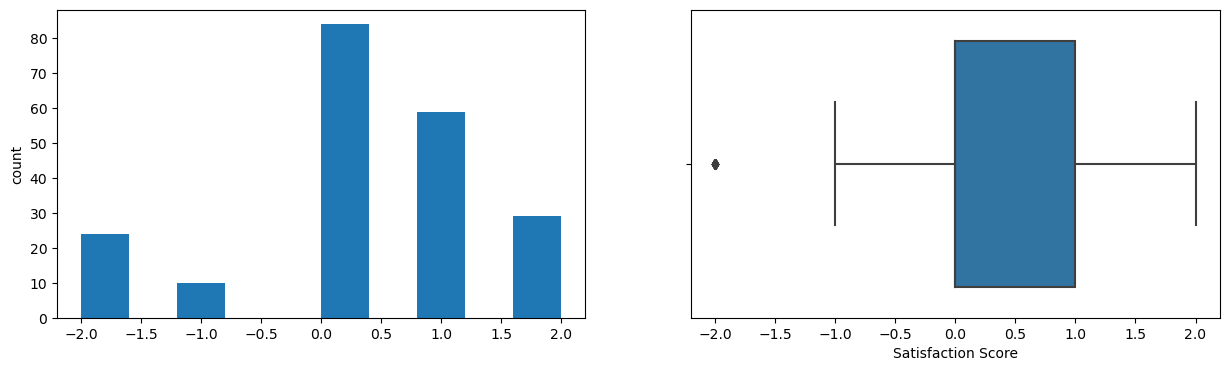

Age
Skew : 0.07


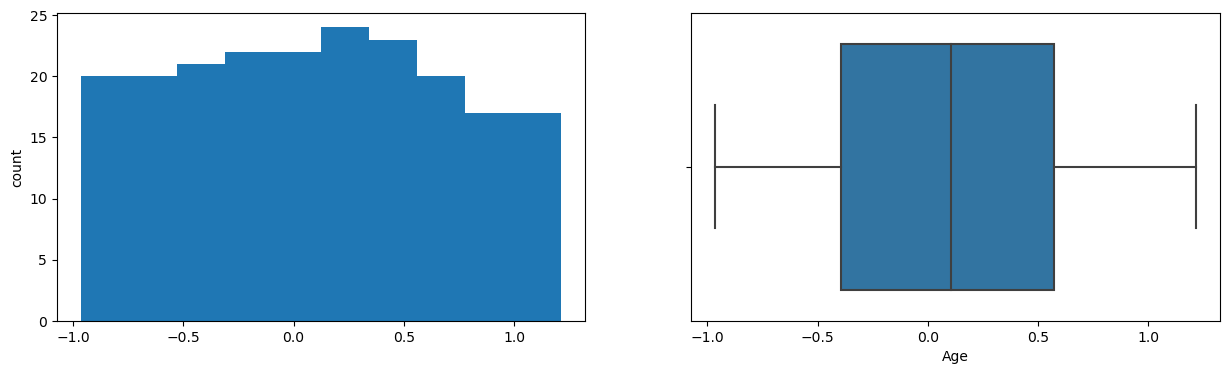

Internet Type_Cable
Skew : 2.65


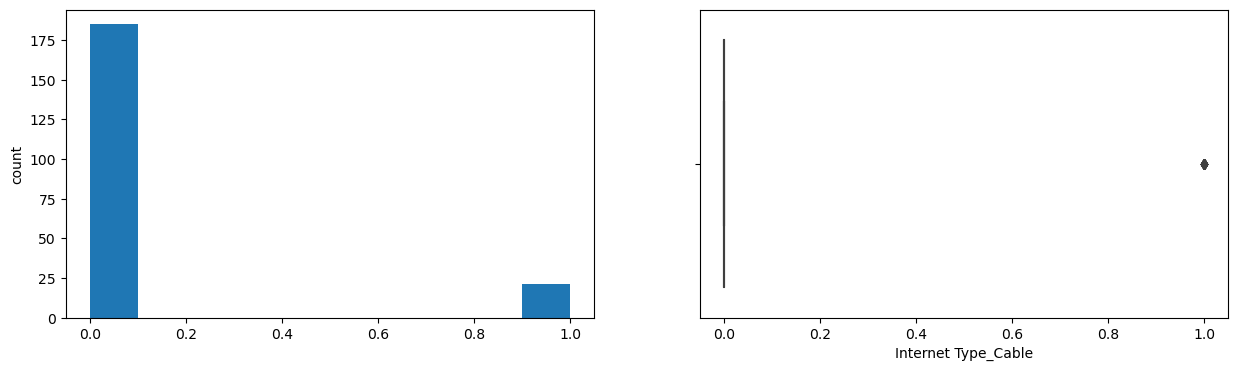

Internet Type_DSL
Skew : 1.21


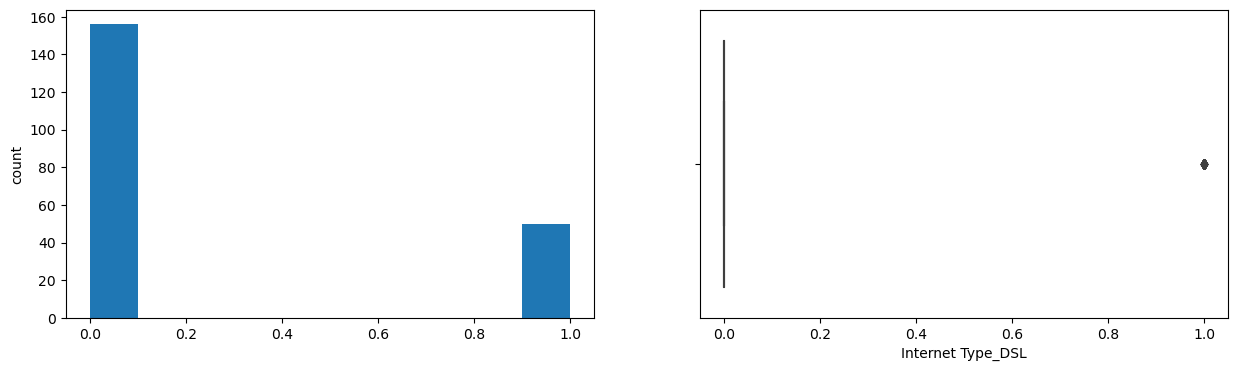

Internet Type_Fiber Optic
Skew : 0.06


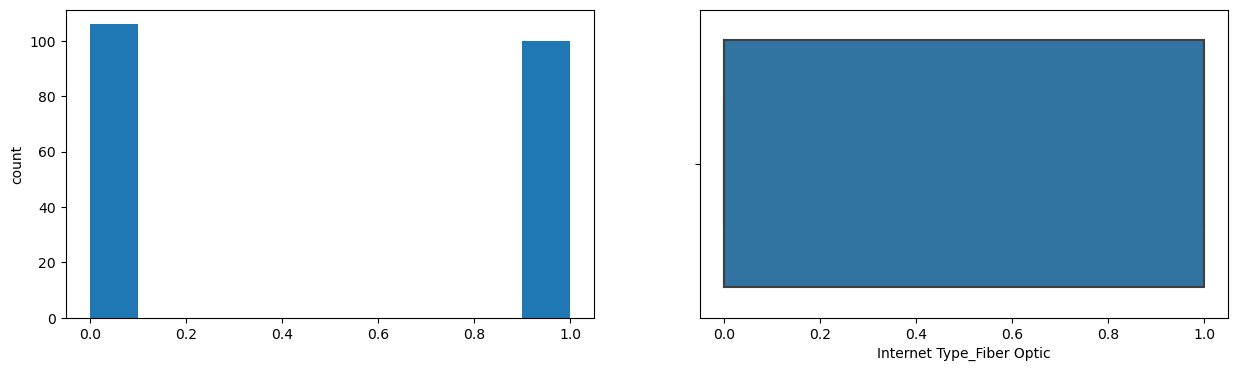

Internet Type_No Service
Skew : 1.77


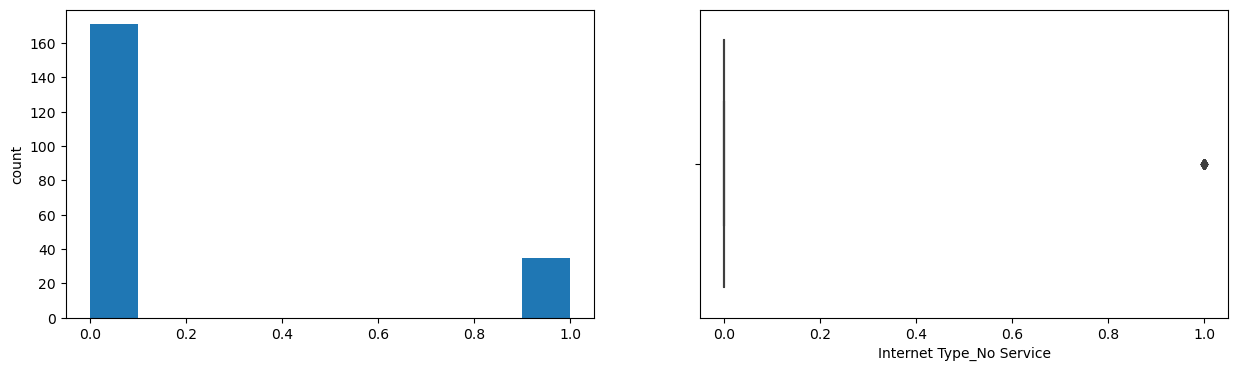

Payment Method_Bank Withdrawal
Skew : -0.61


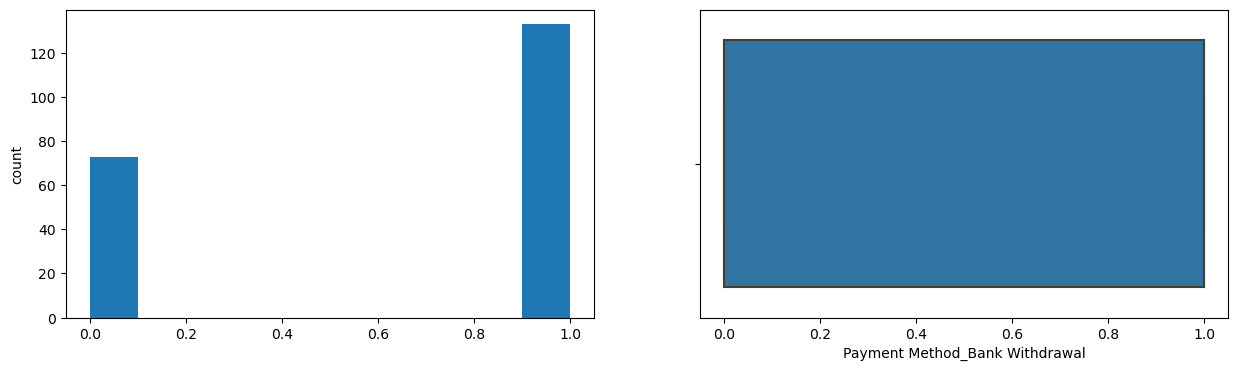

Payment Method_Credit Card
Skew : 0.73


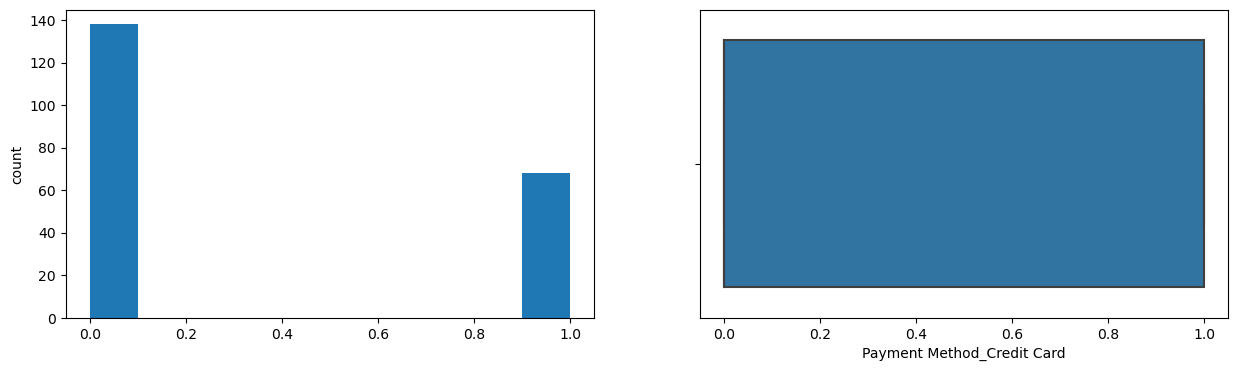

Payment Method_Mailed Check
Skew : 6.23


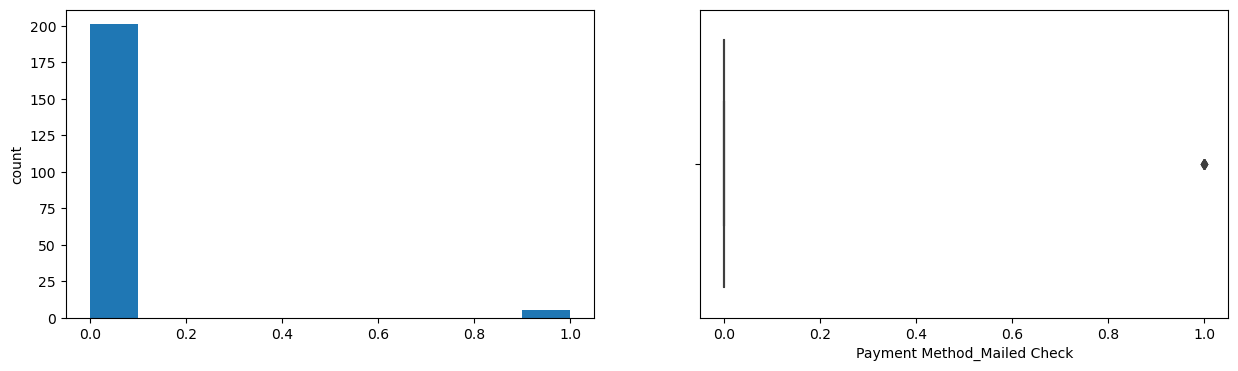

In [88]:
for col in num_fea1:
    print(col)
    print('Skew :', round(cluster_2[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    cluster_2[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x = cluster_2[col])
    plt.show()